In [ ]:
# !pip install -q keras==3.12.0

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
torch.set_default_device("cuda")

In [ ]:
plt.style.use("seaborn-v0_8-notebook")
plt.style.use("petroff10")
plt.set_loglevel("error")

print(f"Keras: {keras.__version__}")
print(f"Numpy: {np.__version__}")

Keras: 3.12.0
Numpy: 2.0.2


In [ ]:
# --- Hyperparameters ---
BATCH_SIZE = 128
LATENT_D = 128
NEURONS = 512
OUT_SHAPE = (
    1,
    28,
    28,
)  # Keras manages batch dim automatically, so we use (28, 28) or (28, 28, 1)
NUM_EPOCHS = 10


def fc_block(x, out_neurons, leak=0.1):
    """
    Helper function equivalent to the PyTorch fcLayer.
    Linear -> LeakyReLU -> LayerNorm
    """
    x = layers.Dense(out_neurons)(x)
    x = layers.LeakyReLU(negative_slope=leak)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    return x


def get_generator(latent_d, neurons, out_shape, sigmoid_g=False, leak=0.2):
    """
    Builds the Generator model.
    """
    inputs = keras.Input(shape=(latent_d,))

    x = fc_block(inputs, neurons, leak)
    x = fc_block(x, neurons, leak)
    x = fc_block(x, neurons, leak)

    # Calculate total flat dimension needed
    flat_dim = int(np.prod(out_shape))

    # Final projection
    x = layers.Dense(flat_dim)(x)

    # Reshape to image dimensions (equivalent to PyTorch View)
    outputs = layers.Reshape(out_shape)(x)

    if sigmoid_g:
        outputs = layers.Activation("sigmoid")(outputs)

    return keras.Model(inputs, outputs, name="generator")


def get_discriminator(input_shape, neurons, leak=0.2):
    """
    Builds the Discriminator model.
    """
    inputs = keras.Input(shape=input_shape)

    # Flatten input (equivalent to PyTorch nn.Flatten)
    x = layers.Flatten()(inputs)

    x = fc_block(x, neurons, leak)
    x = fc_block(x, neurons, leak)
    x = fc_block(x, neurons, leak)

    # Output layer: 1 neuron for binary classification.
    # No activation here because we use from_logits=True in the loss function
    # to match PyTorch's BCEWithLogitsLoss
    outputs = layers.Dense(1)(x)

    return keras.Model(inputs, outputs, name="discriminator")


class GAN(keras.Model):
    """
    Subclassing keras.Model allows us to define the custom training loop
    inside `train_step`.
    """

    def __init__(self, latent_dim):
        super().__init__()
        # 1. Initialize Models
        self.D = get_discriminator((1, 28, 28), NEURONS)
        self.G = get_generator(LATENT_D, NEURONS, OUT_SHAPE, sigmoid_g=True)
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.loss_fn = loss_fn

        self.d_optimizer = d_optimizer([v.value for v in self.D.trainable_weights])
        self.g_optimizer = g_optimizer([v.value for v in self.G.trainable_weights])

        # Define metrics to track
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")
        self.built = True

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def get_config(self):
        config = super().get_config()
        config.update({"latent_dim": self.latent_dim})
        return config

    def train_step(self, real_data):
        # Sample random points in the latent space
        y_real = ops.ones((BATCH_SIZE, 1))
        y_fake = ops.zeros((BATCH_SIZE, 1))

        # Step 1) $\ell ( D( x_{\mathit{real}}) ,\ y_{\mathit{real}})\$ and $\ell ( D(\boldsymbol{x}_{\mathit{fake}}) ,\ y_{\mathit{fake}})$
        self.D.zero_grad()

        # Calculate loss on all-real batch
        error_d_real = self.loss_fn(self.D(real_data), y_real)
        # Calculate gradients for D in backward pass
        error_d_real.backward()

        ## Train with all-fake batch
        # Generate batch of latent vectors $z \sim \mathcal{N}(\vec{0}, 1)$
        z = keras.random.normal(shape=(BATCH_SIZE, self.latent_dim))
        # Generate fake image batch with G
        # Classify all fake batch with D. We will save this to re-use for the 2nd step.
        fake = self.G(z)
        # Why do we detach here? Because we don't want the gradient to impact G.
        # Our goal right now is to update _just_ the discriminator.
        # BUT, we will re-use this fake data for updating the discriminator, so we want to save the
        # non-detached version!
        # Calculate D's loss on the all-fake batch
        error_d_fake = self.loss_fn(self.D(fake.detach()), y_fake)
        # Calculate the gradients for this batch
        error_d_fake.backward()
        # Add the gradients from the all-real and all-fake batches
        error_d = error_d_real + error_d_fake
        # Update D
        self.d_optimizer.step()

        # Step 2) $\ell ( D(\boldsymbol{x}_{\mathit{fake}}) ,\ y_{\mathit{real}})$
        self.G.zero_grad()
        # Since we just updated D, perform another forward pass of all-fake batch through D
        # Calculate G's loss based on this output
        error_g = self.loss_fn(self.D(fake), y_real)
        # Calculate gradients for G
        error_g.backward()
        # Update G
        self.g_optimizer.step()

        # Update metrics
        self.d_loss_tracker.update_state(error_d.item())
        self.g_loss_tracker.update_state(error_g.item())

        return {
            "d_loss": self.d_loss_tracker.result(),
            "g_loss": self.g_loss_tracker.result(),
        }


gan = GAN(latent_dim=LATENT_D).to("cuda")

gan.compile(
    d_optimizer=lambda p: torch.optim.AdamW(p, lr=1e-4),
    g_optimizer=lambda p: torch.optim.AdamW(p, lr=1e-4),
    loss_fn=nn.BCEWithLogitsLoss(),
)

In [ ]:
class ImageOnlyMNIST(torchvision.datasets.MNIST):
    def __getitem__(self, index):
        # Call the parent class to get the tuple
        img, target = super().__getitem__(index)
        # Return only the image
        return img


train_data = ImageOnlyMNIST(
    "./", train=True, transform=transforms.ToTensor(), download=True
)
test_data = ImageOnlyMNIST(
    "./", train=False, transform=transforms.ToTensor(), download=True
)

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=torch.Generator(device="cuda"),
)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

In [ ]:
history = gan.fit(train_loader, epochs=50, verbose=2)

Epoch 1/50
468/468 - 27s - 58ms/step - d_loss: 0.0140 - g_loss: 8.5596
Epoch 2/50
468/468 - 27s - 58ms/step - d_loss: 0.0027 - g_loss: 9.3591
Epoch 3/50
468/468 - 25s - 54ms/step - d_loss: 0.0025 - g_loss: 9.3869
Epoch 4/50
468/468 - 26s - 55ms/step - d_loss: 0.0038 - g_loss: 9.7463
Epoch 5/50
468/468 - 25s - 54ms/step - d_loss: 0.0041 - g_loss: 9.7117
Epoch 6/50
468/468 - 26s - 55ms/step - d_loss: 0.0105 - g_loss: 9.9145
Epoch 7/50
468/468 - 25s - 54ms/step - d_loss: 0.0167 - g_loss: 8.9287
Epoch 8/50
468/468 - 26s - 56ms/step - d_loss: 0.0196 - g_loss: 9.3949
Epoch 9/50
468/468 - 25s - 54ms/step - d_loss: 0.0213 - g_loss: 8.4833
Epoch 10/50
468/468 - 25s - 54ms/step - d_loss: 0.0282 - g_loss: 8.1323
Epoch 11/50
468/468 - 25s - 54ms/step - d_loss: 0.0395 - g_loss: 8.1054
Epoch 12/50
468/468 - 25s - 54ms/step - d_loss: 0.0520 - g_loss: 7.6426
Epoch 13/50
468/468 - 25s - 54ms/step - d_loss: 0.0652 - g_loss: 7.3342
Epoch 14/50
468/468 - 25s - 54ms/step - d_loss: 0.0836 - g_loss: 7.0561
E

In [ ]:
with torch.no_grad():
    noise = torch.randn(
        BATCH_SIZE, LATENT_D
    )  # $\boldsymbol{z} \sim \mathcal{N}(\vec{0}, \boldsymbol{I})$
    fake_digits = gan.G(noise)
    scores = torch.sigmoid(gan.D(fake_digits))

    fake_digits = fake_digits.cpu()
    scores = scores.cpu().numpy().flatten()

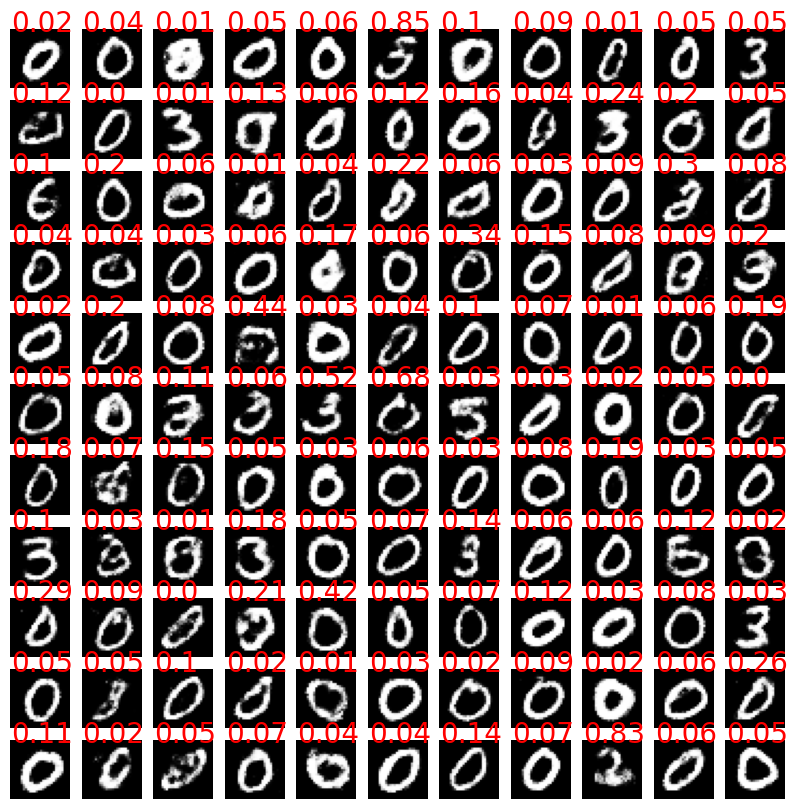

In [ ]:
def plot_gen_imgs(fake_digits, scores=None):
    batch_size = fake_digits.size(0)
    # This code assumes we are working with black-and-white images
    fake_digits = fake_digits.reshape(-1, fake_digits.size(-1), fake_digits.size(-1))
    i_max = int(round(np.sqrt(batch_size)))
    j_max = int(np.floor(batch_size / float(i_max)))
    f, axarr = plt.subplots(i_max, j_max, figsize=(10, 10))
    for i in range(i_max):
        for j in range(j_max):
            indx = i * j_max + j
            axarr[i, j].imshow(
                fake_digits[indx, :].numpy(), cmap="gray", vmin=0, vmax=1
            )
            axarr[i, j].set_axis_off()
            if scores is not None:
                axarr[i, j].text(
                    0.0, 0.5, str(round(scores[indx], 2)), dict(size=20, color="red")
                )


plot_gen_imgs(fake_digits, scores)

<Axes: >

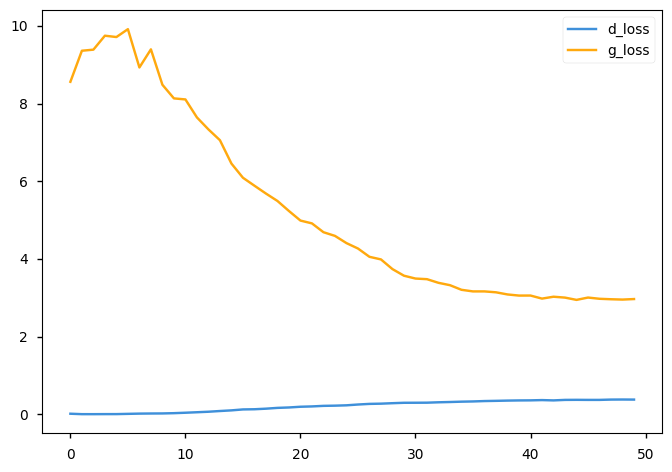

In [ ]:
pd.DataFrame(history.history).plot()